<a href="https://colab.research.google.com/github/nguyenph-git/Deep-Learning/blob/main/FIT5215_3181_Kaggle_Assignment1_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FIT5215 / FIT3181 Assignment 1 - Kaggle Starter Notebook

This notebook provides a complete, deliberately simple workflow: download the training data, load the hidden-label Kaggle test set, create a validation split, train a starter CNN, and write a valid Kaggle submission.

The starter notebook is intended to run in **Google Colab with a GPU runtime**. Improve the data augmentation, model architecture, optimization, and validation procedure for your own submission.

## Before you start

1. In Colab, select **Runtime → Change runtime type → GPU**.
2. Make your own copy of this notebook.
3. On the competition **Data** tab, download `test_set.zip` and upload it to the Colab Files pane. When extracted, it creates a `test_set` folder containing the `test_dataset` image folder and the sample submission template `my_solution.csv`.

   **If your computer automatically decompresses the file downloaded from Kaggle, compress the complete extracted `test_set` folder again, name the new archive `test_set.zip`, and upload that ZIP file to Colab.**

4. The labelled training set is downloaded separately from Google Drive. Use the [primary training archive](https://drive.google.com/file/d/10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9/view?usp=sharing), or manually switch to the [backup training archive](https://drive.google.com/file/d/1uc7uQ5myz7k74ZO460Q04B35_GekQeGi/view?usp=sharing) if the primary link is unavailable.

The release contains **9,466 labelled training images across 20 classes** and **11,681 unlabelled 64×64 test images**. The submission template contains the columns `ID,Label`. Use only the provided training labels and follow the assignment and competition rules.

In [ ]:
from __future__ import annotations

import copy
import os
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 2026
ROOT = Path('/content') if Path('/content').is_dir() else Path.cwd()
TRAIN_ARCHIVE = ROOT / 'Animals_Dataset.zip'
TRAIN_DIR = ROOT / 'FIT5215_Dataset'
TEST_ARCHIVE = ROOT / 'test_set.zip'
TEST_PACKAGE_DIR = ROOT / 'test_set'
TEST_DIR = TEST_PACKAGE_DIR / 'test_dataset'
SUBMISSION_TEMPLATE = TEST_PACKAGE_DIR / 'my_solution.csv'

def seed_everything(seed: int) -> None:
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Working directory:', ROOT)
print('PyTorch:', torch.__version__)
print('Device:', device)
if device.type != 'cuda':
    print('Warning: training will be much slower without a GPU runtime.')

Working directory: /content
PyTorch: 2.11.0+cu128
Device: cuda


## 1. Download the labelled training set

Run the primary download below. If that link is unavailable, comment it out and uncomment the backup download. Both commands save the archive with the same filename.

In [ ]:
# Primary download
!gdown --fuzzy 'https://drive.google.com/file/d/10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9/view?usp=sharing' -O Animals_Dataset.zip

# Backup download: use this only if the primary link is unavailable.
# !gdown --fuzzy 'https://drive.google.com/file/d/1uc7uQ5myz7k74ZO460Q04B35_GekQeGi/view?usp=sharing' -O Animals_Dataset.zip

!unzip -q -o Animals_Dataset.zip
assert TRAIN_DIR.is_dir(), f'Training folder not found: {TRAIN_DIR}'
print('Training data ready:', TRAIN_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9
From (redirected): https://drive.google.com/uc?id=10Y65ykpja1t6UWt3imPPbZkqhe0kOPL9&confirm=t&uuid=0655a760-6d5d-41a0-a44a-d7c35f4bb7d8
To: /content/Animals_Dataset.zip
100% 643M/643M [00:10<00:00, 63.0MB/s]
Training data ready: /content/FIT5215_Dataset


## 2. Load the Kaggle test data and submission template

Upload `test_set.zip` to the Colab Files pane. It must extract into the same layout as the Kaggle download:

```text
test_set.zip
└── test_set/
    ├── test_dataset/
    │   ├── 00000_animal.jpeg
    │   └── ...
    └── my_solution.csv
```

**If your computer automatically decompresses the Kaggle download, compress the complete extracted `test_set` folder again, name the archive `test_set.zip`, and then upload it to Colab.** Keep the names and folder structure unchanged.

In [ ]:
EXPECTED_TEST_IMAGES = 11_681

if not TEST_DIR.is_dir() or not SUBMISSION_TEMPLATE.is_file():
    assert TEST_ARCHIVE.is_file(), (
        'Upload test_set.zip to the Colab Files pane before continuing.'
    )
    with zipfile.ZipFile(TEST_ARCHIVE) as archive:
        archive.extractall(ROOT)

assert TEST_PACKAGE_DIR.is_dir(), (
    'The ZIP must contain a top-level folder named test_set.'
)
assert TEST_DIR.is_dir(), (
    'The test_set folder must contain the test_dataset image folder.'
)
test_paths = sorted(TEST_DIR.glob('*_animal.jpeg'))
test_ids = [int(path.name.split('_', 1)[0]) for path in test_paths]
assert len(test_paths) == EXPECTED_TEST_IMAGES, (
    f'Expected {EXPECTED_TEST_IMAGES:,} test images, found {len(test_paths):,}.'
)
assert test_ids == list(range(EXPECTED_TEST_IMAGES)), (
    'Test image IDs must run from 0 to 11680.'
)
assert SUBMISSION_TEMPLATE.is_file(), (
    'The test_set folder must contain my_solution.csv.'
)
submission_template = pd.read_csv(SUBMISSION_TEMPLATE)
assert submission_template.columns.tolist() == ['ID', 'Label']
assert submission_template['ID'].tolist() == test_ids
print(f'Test data ready: {len(test_paths):,} images')
display(submission_template.head())

Test data ready: 11,681 images


,ID,Label
0,0,birds
1,1,birds
2,2,birds
3,3,birds
4,4,birds


## 3. Build training, validation, and test datasets

The split is stratified so every class is represented in both training and validation. Training augmentation is intentionally mild because the Kaggle images are only 64×64. Validation and test preprocessing are deterministic.

In [ ]:
EXPECTED_CLASS_NAMES = [
    'birds', 'bottles', 'breads', 'butterflies', 'cakes', 'cats',
    'chickens', 'cows', 'dogs', 'ducks', 'elephants', 'fishes',
    'handguns', 'horses', 'lions', 'lipsticks', 'seals', 'snakes',
    'spiders', 'vases',
]
CLASS_NAME_CORRECTIONS = {'butterfiles': 'butterflies'}
MEAN = (0.5, 0.5, 0.5)
STD = (0.5, 0.5, 0.5)
VALIDATION_FRACTION = 0.15

train_transform = transforms.Compose([
    transforms.Resize((72, 72)),
    transforms.RandomCrop((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
evaluation_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

index_dataset = datasets.ImageFolder(TRAIN_DIR)
class_names = [
    CLASS_NAME_CORRECTIONS.get(name, name) for name in index_dataset.classes
]
if class_names != EXPECTED_CLASS_NAMES:
    raise RuntimeError(f'Unexpected training class order: {class_names}')
targets = np.asarray(index_dataset.targets, dtype=np.int64)
rng = np.random.default_rng(SEED)
train_indices = []
validation_indices = []
for class_index in range(len(class_names)):
    class_indices = np.flatnonzero(targets == class_index)
    rng.shuffle(class_indices)
    validation_count = max(1, int(round(len(class_indices) * VALIDATION_FRACTION)))
    validation_indices.extend(class_indices[:validation_count].tolist())
    train_indices.extend(class_indices[validation_count:].tolist())
train_indices = sorted(train_indices)
validation_indices = sorted(validation_indices)

training_augmented = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
training_evaluation = datasets.ImageFolder(TRAIN_DIR, transform=evaluation_transform)
train_dataset = Subset(training_augmented, train_indices)
train_evaluation_dataset = Subset(training_evaluation, train_indices)
validation_dataset = Subset(training_evaluation, validation_indices)

class KaggleTestDataset(Dataset):
    def __init__(self, paths: list[Path], transform):
        self.paths = paths
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        path = self.paths[index]
        test_id = int(path.name.split('_', 1)[0])
        with Image.open(path) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, test_id

test_dataset = KaggleTestDataset(test_paths, evaluation_transform)
print('Classes:', class_names)

Classes: ['birds', 'bottles', 'breads', 'butterflies', 'cakes', 'cats', 'chickens', 'cows', 'dogs', 'ducks', 'elephants', 'fishes', 'handguns', 'horses', 'lions', 'lipsticks', 'seals', 'snakes', 'spiders', 'vases']


In [ ]:
BATCH_SIZE = 128
NUM_WORKERS = min(2, os.cpu_count() or 1)
pin_memory = device.type == 'cuda'
loader_generator = torch.Generator().manual_seed(SEED)

def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=loader_generator, worker_init_fn=seed_worker,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)
train_evaluation_loader = DataLoader(
    train_evaluation_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)
validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)
print(f'Train: {len(train_dataset):,}')
print(f'Validation: {len(validation_dataset):,}')
print(f'Test: {len(test_dataset):,}')

Train: 8,047
Validation: 1,419
Test: 11,681


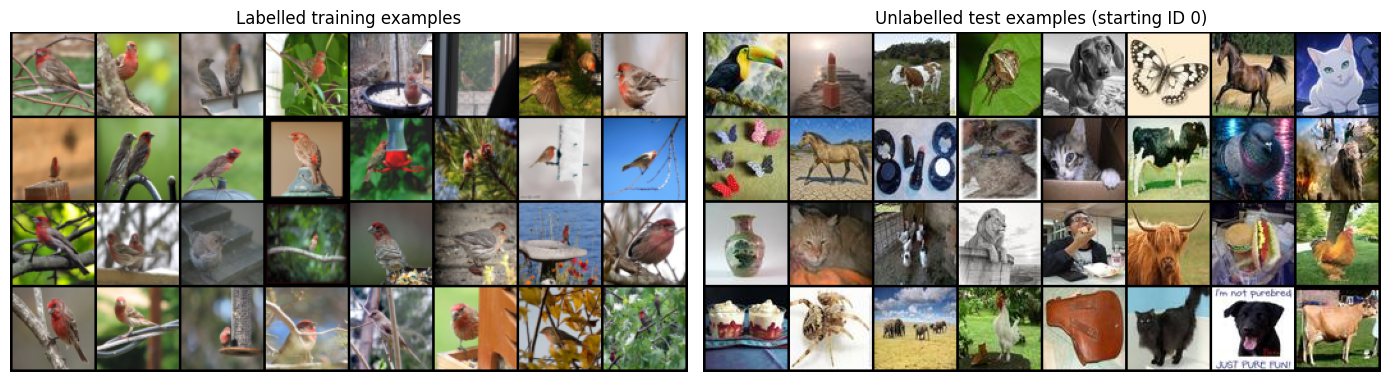

Example training label: birds


In [ ]:
def denormalize(batch: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(MEAN).view(1, 3, 1, 1)
    std = torch.tensor(STD).view(1, 3, 1, 1)
    return (batch.cpu() * std + mean).clamp(0, 1)

images, labels = next(iter(train_evaluation_loader))
test_images, displayed_test_ids = next(iter(test_loader))
figure, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(make_grid(denormalize(images[:32]), nrow=8).permute(1, 2, 0))
axes[0].set_title('Labelled training examples')
axes[0].axis('off')
axes[1].imshow(make_grid(denormalize(test_images[:32]), nrow=8).permute(1, 2, 0))
axes[1].set_title(f'Unlabelled test examples (starting ID {int(displayed_test_ids[0])})')
axes[1].axis('off')
figure.tight_layout()
plt.show()
print('Example training label:', class_names[int(labels[0])])

## 4. Define a starter CNN

This compact network is a starting point, not a target solution. You are expected to make and justify your own improvements within the assignment rules.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.layers(inputs)

class StarterCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout=0.05),
            ConvBlock(32, 64, dropout=0.10),
            ConvBlock(64, 128, dropout=0.15),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(inputs))

model = StarterCNN(num_classes=len(class_names)).to(device)
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
print(model)
print(f'Trainable parameters: {trainable_parameters:,}')

StarterCNN(
  (features): Sequential(
    (0): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.05, inplace=False)
      )
    )
    (1): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64,

## 5. Train and select the best validation checkpoint

Only validation performance is used for model selection. The Kaggle test set remains unlabelled and is used once for final prediction.

In [ ]:
def run_epoch(model, loader, loss_function, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    for images, labels in loader:
        images = images.to(device=device, dtype=torch.float32, non_blocking=True)
        labels = labels.to(device=device, dtype=torch.long, non_blocking=True)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = loss_function(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += int((logits.argmax(dim=1) == labels).sum())
        total_examples += batch_size
    return total_loss / total_examples, total_correct / total_examples

def fit(model, train_loader, validation_loader, loss_function, optimizer, epochs):
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=max(1, epochs)
    )
    history = []
    best_score = (-1.0, float('-inf'))
    best_state = None
    best_epoch = 0
    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(
            model, train_loader, loss_function, optimizer
        )
        validation_loss, validation_accuracy = run_epoch(
            model, validation_loader, loss_function
        )
        learning_rate = float(optimizer.param_groups[0]['lr'])
        scheduler.step()
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'validation_loss': validation_loss,
            'validation_accuracy': validation_accuracy,
            'learning_rate': learning_rate,
        })
        score = (validation_accuracy, -validation_loss)
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
        print(
            f'Epoch {epoch:02d}/{epochs:02d} | '
            f'train loss {train_loss:.4f}, acc {train_accuracy:.2%} | '
            f'val loss {validation_loss:.4f}, acc {validation_accuracy:.2%}'
        )
    return pd.DataFrame(history), best_state, best_epoch

In [ ]:
EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

loss_function = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
history, best_state, best_epoch = fit(
    model, train_loader, validation_loader, loss_function, optimizer, EPOCHS
)
model.load_state_dict(best_state)
model.to(device)
validation_loss, validation_accuracy = run_epoch(
    model, validation_loader, loss_function
)
checkpoint_path = ROOT / 'starter_cnn_best.pt'
torch.save(
    {'model_state_dict': model.state_dict(), 'class_names': class_names},
    checkpoint_path,
)
print(f'Best epoch: {best_epoch}')
print(f'Best validation accuracy: {validation_accuracy:.2%}')
print('Checkpoint:', checkpoint_path)

Epoch 01/15 | train loss 2.6919, acc 18.28% | val loss 2.5152, acc 23.40%
Epoch 02/15 | train loss 2.4636, acc 26.35% | val loss 2.3207, acc 31.15%
Epoch 03/15 | train loss 2.3169, acc 31.29% | val loss 2.2127, acc 35.73%
Epoch 04/15 | train loss 2.1956, acc 35.32% | val loss 2.0582, acc 41.79%
Epoch 05/15 | train loss 2.0917, acc 38.98% | val loss 1.9192, acc 46.30%
Epoch 06/15 | train loss 1.9973, acc 42.98% | val loss 1.9045, acc 47.29%
Epoch 07/15 | train loss 1.9160, acc 44.61% | val loss 1.7668, acc 50.74%
Epoch 08/15 | train loss 1.8437, acc 47.07% | val loss 1.7353, acc 51.23%
Epoch 09/15 | train loss 1.7965, acc 48.80% | val loss 1.6612, acc 55.32%
Epoch 10/15 | train loss 1.7540, acc 50.63% | val loss 1.6467, acc 54.12%
Epoch 11/15 | train loss 1.6976, acc 52.28% | val loss 1.5511, acc 59.62%
Epoch 12/15 | train loss 1.6750, acc 53.76% | val loss 1.5237, acc 59.48%
Epoch 13/15 | train loss 1.6349, acc 54.50% | val loss 1.5063, acc 60.54%
Epoch 14/15 | train loss 1.6390, acc 5

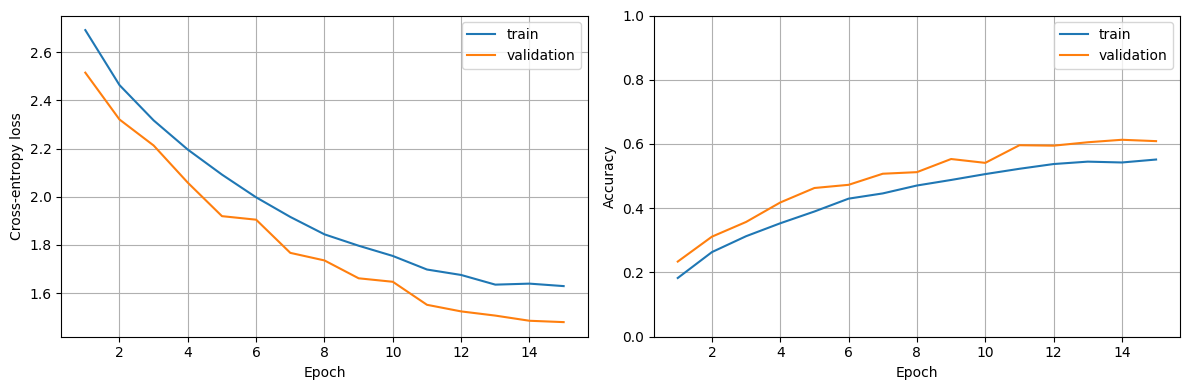

In [ ]:
figure, (loss_axis, accuracy_axis) = plt.subplots(1, 2, figsize=(12, 4))
loss_axis.plot(history['epoch'], history['train_loss'], label='train')
loss_axis.plot(history['epoch'], history['validation_loss'], label='validation')
loss_axis.set(xlabel='Epoch', ylabel='Cross-entropy loss')
loss_axis.grid(True)
loss_axis.legend()
accuracy_axis.plot(history['epoch'], history['train_accuracy'], label='train')
accuracy_axis.plot(
    history['epoch'], history['validation_accuracy'], label='validation'
)
accuracy_axis.set(xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1))
accuracy_axis.grid(True)
accuracy_axis.legend()
figure.tight_layout()
plt.show()

## 6. Predict the test set and create `submission.csv`

Kaggle expects exactly 11,681 rows with the string columns `ID,Label`. Prediction IDs are carried through the data loader and merged into the public template, so batching cannot silently reorder the submission.

In [ ]:
@torch.inference_mode()
def predict(model, loader):
    model.eval()
    predicted_ids = []
    predicted_indices = []
    for images, image_ids in loader:
        images = images.to(device=device, dtype=torch.float32, non_blocking=True)
        predicted_indices.extend(model(images).argmax(dim=1).cpu().tolist())
        predicted_ids.extend(image_ids.tolist())
    return predicted_ids, predicted_indices

predicted_ids, predicted_indices = predict(model, test_loader)
prediction_frame = pd.DataFrame({
    'ID': predicted_ids,
    'Label': [class_names[index] for index in predicted_indices],
})
if prediction_frame['ID'].duplicated().any():
    raise RuntimeError('Predictions contain duplicate IDs.')
if set(prediction_frame['Label']) - set(EXPECTED_CLASS_NAMES):
    raise RuntimeError('Predictions contain an invalid class label.')

submission = submission_template[['ID']].merge(
    prediction_frame, on='ID', how='left', validate='one_to_one'
)
if submission.columns.tolist() != ['ID', 'Label']:
    raise RuntimeError('Submission must contain exactly ID,Label.')
if len(submission) != EXPECTED_TEST_IMAGES or submission['Label'].isna().any():
    raise RuntimeError('Submission rows do not match the test set.')
if submission['ID'].tolist() != list(range(EXPECTED_TEST_IMAGES)):
    raise RuntimeError('Submission IDs are not ordered from 0 to 11680.')

SUBMISSION_PATH = ROOT / 'submission.csv'
submission.to_csv(SUBMISSION_PATH, index=False)
print('Submission:', SUBMISSION_PATH)
print('Rows:', len(submission))
display(submission.head())
display(submission['Label'].value_counts().sort_index())

Submission: /content/submission.csv
Rows: 11681


,ID,Label
0,0,fishes
1,1,lions
2,2,horses
3,3,spiders
4,4,horses


,count
Label,
birds,16
bottles,13
breads,21
butterflies,529
cakes,48
cats,263
chickens,622
cows,1708
dogs,31


## 7. Submit and improve

Download `submission.csv`, open your cohort's Kaggle competition, choose **Submit Predictions**, and upload the CSV. Do not upload the unchanged `my_solution.csv` placeholder.

Useful next experiments include stronger but still mild augmentation, deeper model architectures, regularization, learning-rate schedules, class-balanced sampling, and permitted pretrained models. Keep the validation split fixed while comparing experiments, and preserve the exact test IDs and canonical string labels.

In [ ]:
# Run this cell in Google Colab to download the completed submission.
try:
    from google.colab import files
    files.download(str(SUBMISSION_PATH))
except ImportError:
    print(f'Not running in Colab. Submission is saved at {SUBMISSION_PATH}.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>